 02 — Estimasi Parameter

**Pertanyaan penelitian yang dijawab:** No. 1 — Berapa estimasi peluang sebuah Pull Request di microsoft/vscode akan berhasil ter-merge?

**Anggota:** [dhanurefian ] — Estimation Analyst

## Pengungkapan Penggunaan AI

**Anggota:** [dhanu refian] — Estimation Analyst | **Alat yang digunakan:** Claude

| Tugas | Alat | Ringkasan prompt | Output dimodifikasi? |
|-------|------|------------------|----------------------|
| Implementasi fungsi `mle_bernoulli` di `src/estimator.py` | Claude | "Buatkan `mle_bernoulli(data)` dengan rumus k/n sesuai Tsun (2020) hal. 254" | [ Tidak] |
| Scaffolding kode plot kurva likelihood dan Beta posterior | Claude | "Berikan contoh kode plot log-likelihood Bernoulli dan kurva Beta posterior" | [ Tidak] |
| Bantuan debugging error path CSV (`FileNotFoundError`) | Claude | "Error FileNotFoundError saat baca data/clean/pull_requests_clean.csv" | Tidak — hanya perbaikan path |

**Ditulis sepenuhnya tanpa AI:**
- Sel interpretasi atas hasil θ̂ ≈ 0,87 dan maknanya untuk vscode
- Sel interpretasi bentuk Beta posterior dan kenapa posterior tajam
- Sel ringkasan akhir yang menghubungkan output estimasi ke notebook berikutnya (`03_confidence_interval.ipynb`)
- Sel interpretasi hasil MLE Poisson untuk jumlah komentar issue

In [23]:

import sys
!{sys.executable} -m pip install scipy numpy pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.estimator import (
    mle_bernoulli,
    mle_poisson,
    beta_posterior,
    log_likelihood_bernoulli,
    log_likelihood_poisson,
)
from scipy.stats import beta as beta_dist

pr = pd.read_csv("../data/clean/pull_requests_clean.csv")
iss = pd.read_csv("../data/clean/issues_clean.csv")


In [19]:

theta_hat = mle_bernoulli(pr['is_merged'])
k = int(pr['is_merged'].sum())          
m = int((~pr['is_merged']).sum())       
post = beta_posterior(k, m)

grid = np.linspace(0.01, 0.99, 500) 

Text(0, 0.5, 'log-likelihood')

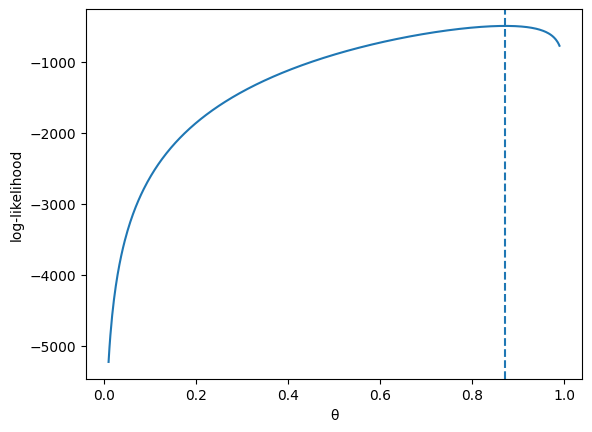

In [20]:
# --- Plot kurva log-likelihood ---
grid = np.linspace(0.01, 0.99, 500)
plt.plot(grid, log_likelihood_bernoulli(grid, k, k + m))
plt.axvline(theta_hat, ls='--')
plt.xlabel("θ"); plt.ylabel("log-likelihood")


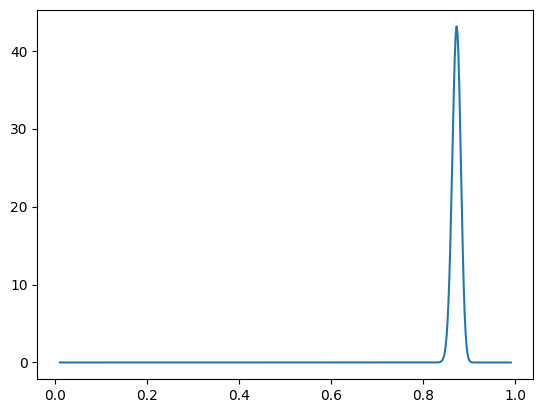

In [24]:
# --- Plot Beta posterior ---
plt.plot(grid, beta_dist.pdf(grid, post['alpha'], post['beta']))

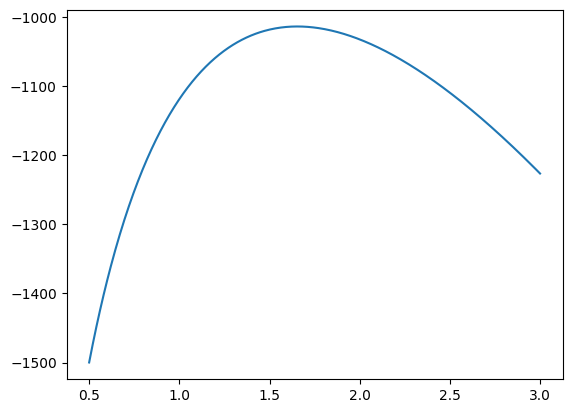

In [22]:
# --- Demonstrasi Poisson: jumlah komentar per issue ---
lam_hat = mle_poisson(iss['comments_count'])
grid_l = np.linspace(0.5, 3.0, 500)
plt.plot(grid_l, log_likelihood_poisson(grid_l, iss['comments_count']))